In [1]:

import astropy.units as u
import gizmo_analysis as gizmo
import matplotlib.pyplot as plt
import numpy as np
from astropy.cosmology import Planck18 as cosmo

%config InlineBackend.figure_format = 'retina'

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [12]:
redshifts = np.linspace(3, 0, 20)

In [ ]:
sim_dir = "/mnt/ceph/users/firesims/fire2/public_release/core/m12i_res7100/"

particles = []
for z in redshifts:
    part = gizmo.io.Read.read_snapshots(
        ["dark", "star"], "redshift", z, sim_dir, snapshot_directory="output"
    )

    p = {
        "pos": part["dark"].prop("host.distance.principal"),  # (N, 3) in kpc
        "mass": np.array(part["dark"]["mass"]),  # (N_dm,) in Msun
        "stars_pos": part["star"].prop("host.distance.principal"),  # (N, 3) in kpc
        "stars_mass": np.array(part["star"]["mass"]),  # (N_stars,) in Msun
    }
    particles.append(p)


# in utilities.simulation.Snapshot():
* reading:  mnt/ceph/users/firesims/fire2/public_release/core/m12i_res7100/snapshot_times.txt

* input redshift = 3.0:  using snapshot index = 120, redshift = 3.000


# in gizmo_analysis.gizmo_io.Read():
* reading header from:  mnt/ceph/users/firesims/fire2/public_release/core/m12i_res7100/output/snapdir_120/snapshot_120.0.hdf5
  snapshot contains the following number of particles:
    dark      (id = 1): 70514272 particles
    dark2     (id = 2): 5513331 particles
    gas       (id = 0): 70032348 particles
    star      (id = 4): 483237 particles
    blackhole (id = 5): 0 particles

* reading the following
  species: ['dark', 'star']

* reading particles from:
    snapshot_120.0.hdf5
    snapshot_120.1.hdf5
    snapshot_120.2.hdf5
    snapshot_120.3.hdf5

* reading cosmological parameters from:  mnt/ceph/users/firesims/fire2/public_release/core/m12i_res7100/initial_condition/ic_agora_m12i.conf

* checking sanity of particle properties


# in gizm

In [4]:
np.logspace(-1, 2.5, 100)

array([1.00000000e-01, 1.08480964e-01, 1.17681195e-01, 1.27661695e-01,
       1.38488637e-01, 1.50233808e-01, 1.62975083e-01, 1.76796941e-01,
       1.91791026e-01, 2.08056754e-01, 2.25701972e-01, 2.44843675e-01,
       2.65608778e-01, 2.88134963e-01, 3.12571585e-01, 3.39080668e-01,
       3.67837977e-01, 3.99034183e-01, 4.32876128e-01, 4.69588196e-01,
       5.09413801e-01, 5.52617002e-01, 5.99484250e-01, 6.50326293e-01,
       7.05480231e-01, 7.65311755e-01, 8.30217568e-01, 9.00628020e-01,
       9.77009957e-01, 1.05986982e+00, 1.14975700e+00, 1.24726747e+00,
       1.35304777e+00, 1.46779927e+00, 1.59228279e+00, 1.72732372e+00,
       1.87381742e+00, 2.03273520e+00, 2.20513074e+00, 2.39214708e+00,
       2.59502421e+00, 2.81510728e+00, 3.05385551e+00, 3.31285189e+00,
       3.59381366e+00, 3.89860370e+00, 4.22924287e+00, 4.58792343e+00,
       4.97702356e+00, 5.39912314e+00, 5.85702082e+00, 6.35375264e+00,
       6.89261210e+00, 7.47717205e+00, 8.11130831e+00, 8.79922544e+00,
      

In [ ]:
# Compute enclosed mass profiles for each snapshot

r_bins = np.logspace(-1, 2.5, 100)  # 0.1 to ~300 kpc
r_cen = 0.5 * (r_bins[:-1] + r_bins[1:])

enclosed_masses = []
for i, p in enumerate(particles):
    r = np.linalg.norm(p["pos"], axis=1)  # physical radius in kpc

    # Compute enclosed mass as function of radius
    M_enc = np.array([p["mass"][r < rr].sum() for rr in r_bins])
    enclosed_masses.append(M_enc)

enclosed_masses = np.array(enclosed_masses)  # shape: (n_snapshots, n_radii)


In [20]:
particles[0]["stars_mass"].sum()

np.float32(2.6704868e+09)

In [8]:
idx = np.argmin(np.abs(r_bins - 50))
M_at_r = enclosed_masses[:, idx]

M_at_r

array([1.4284970e+11, 1.4280016e+11, 1.3774261e+11, 1.3580518e+11,
       1.4463871e+11, 1.7756047e+11, 2.0066004e+11, 1.9916354e+11,
       2.0428603e+11, 1.9770702e+11, 2.1236156e+11, 2.5889469e+11,
       2.7016187e+11, 2.4837906e+11, 2.5194929e+11, 2.7419486e+11,
       2.6584937e+11, 2.8909391e+11, 2.9039926e+11, 2.9453625e+11],
      dtype=float32)

In [9]:
cosmo.lookback_time(redshifts).to(u.Gyr)

<Quantity [11.64313146, 11.25124537, 10.72592374,  9.99586158,  8.93519585,
            7.30837689,  4.64981944,  0.        ] Gyr>

In [10]:
M_at_r

array([1.4284970e+11, 1.4280016e+11, 1.3774261e+11, 1.3580518e+11,
       1.4463871e+11, 1.7756047e+11, 2.0066004e+11, 1.9916354e+11,
       2.0428603e+11, 1.9770702e+11, 2.1236156e+11, 2.5889469e+11,
       2.7016187e+11, 2.4837906e+11, 2.5194929e+11, 2.7419486e+11,
       2.6584937e+11, 2.8909391e+11, 2.9039926e+11, 2.9453625e+11],
      dtype=float32)

In [46]:
import gala.potential as gp

In [54]:
mw['halo']

<NFWPotential: m=5.54e+11 solMass, r_s=15.63 kpc, a=1.00 , b=1.00 , c=1.00  (kpc,Myr,solMass,rad)>

In [ ]:
gp.TimeInterpolatedPotential(
    
)

In [71]:
static_mw["halo"].parameters["m"]

<Quantity 5.5427e+11 solMass>

In [75]:
static_mw = gp.MilkyWayPotential(version='v2')

time_knots = np.linspace(0, 12, 20) * u.Gyr

# use y = mx + c
# t < 3.5 Gyr: linear from (0, 0.45) to (3.5, 0.88)
# t >= 3.5 Gyr: linear from (3.5, 0.88) to (12, 1.0)
mass_at_knot = np.zeros_like(time_knots.value) * u.Msun
for i, t in enumerate(time_knots.value):
    if t < 3.5:
        mass_at_knot[i] = (0.45 + (0.88 - 0.45) / 3.5 * t) * u.Msun
    else:
        mass_at_knot[i] = (0.88 + (1.0 - 0.88) / (12 - 3.5) * (t - 3.5)) * u.Msun
mass_at_knot *= static_mw["halo"].parameters["m"].value

In [82]:
mw = gp.MilkyWayPotential(version='v2')
growing_mw_halo = gp.TimeInterpolatedPotential(
    gp.NFWPotential, time_knots, m=mass_at_knot, r_s=15.63 * u.kpc, units="galactic"
)
mw.lock = False
mw['halo'] = growing_mw_halo

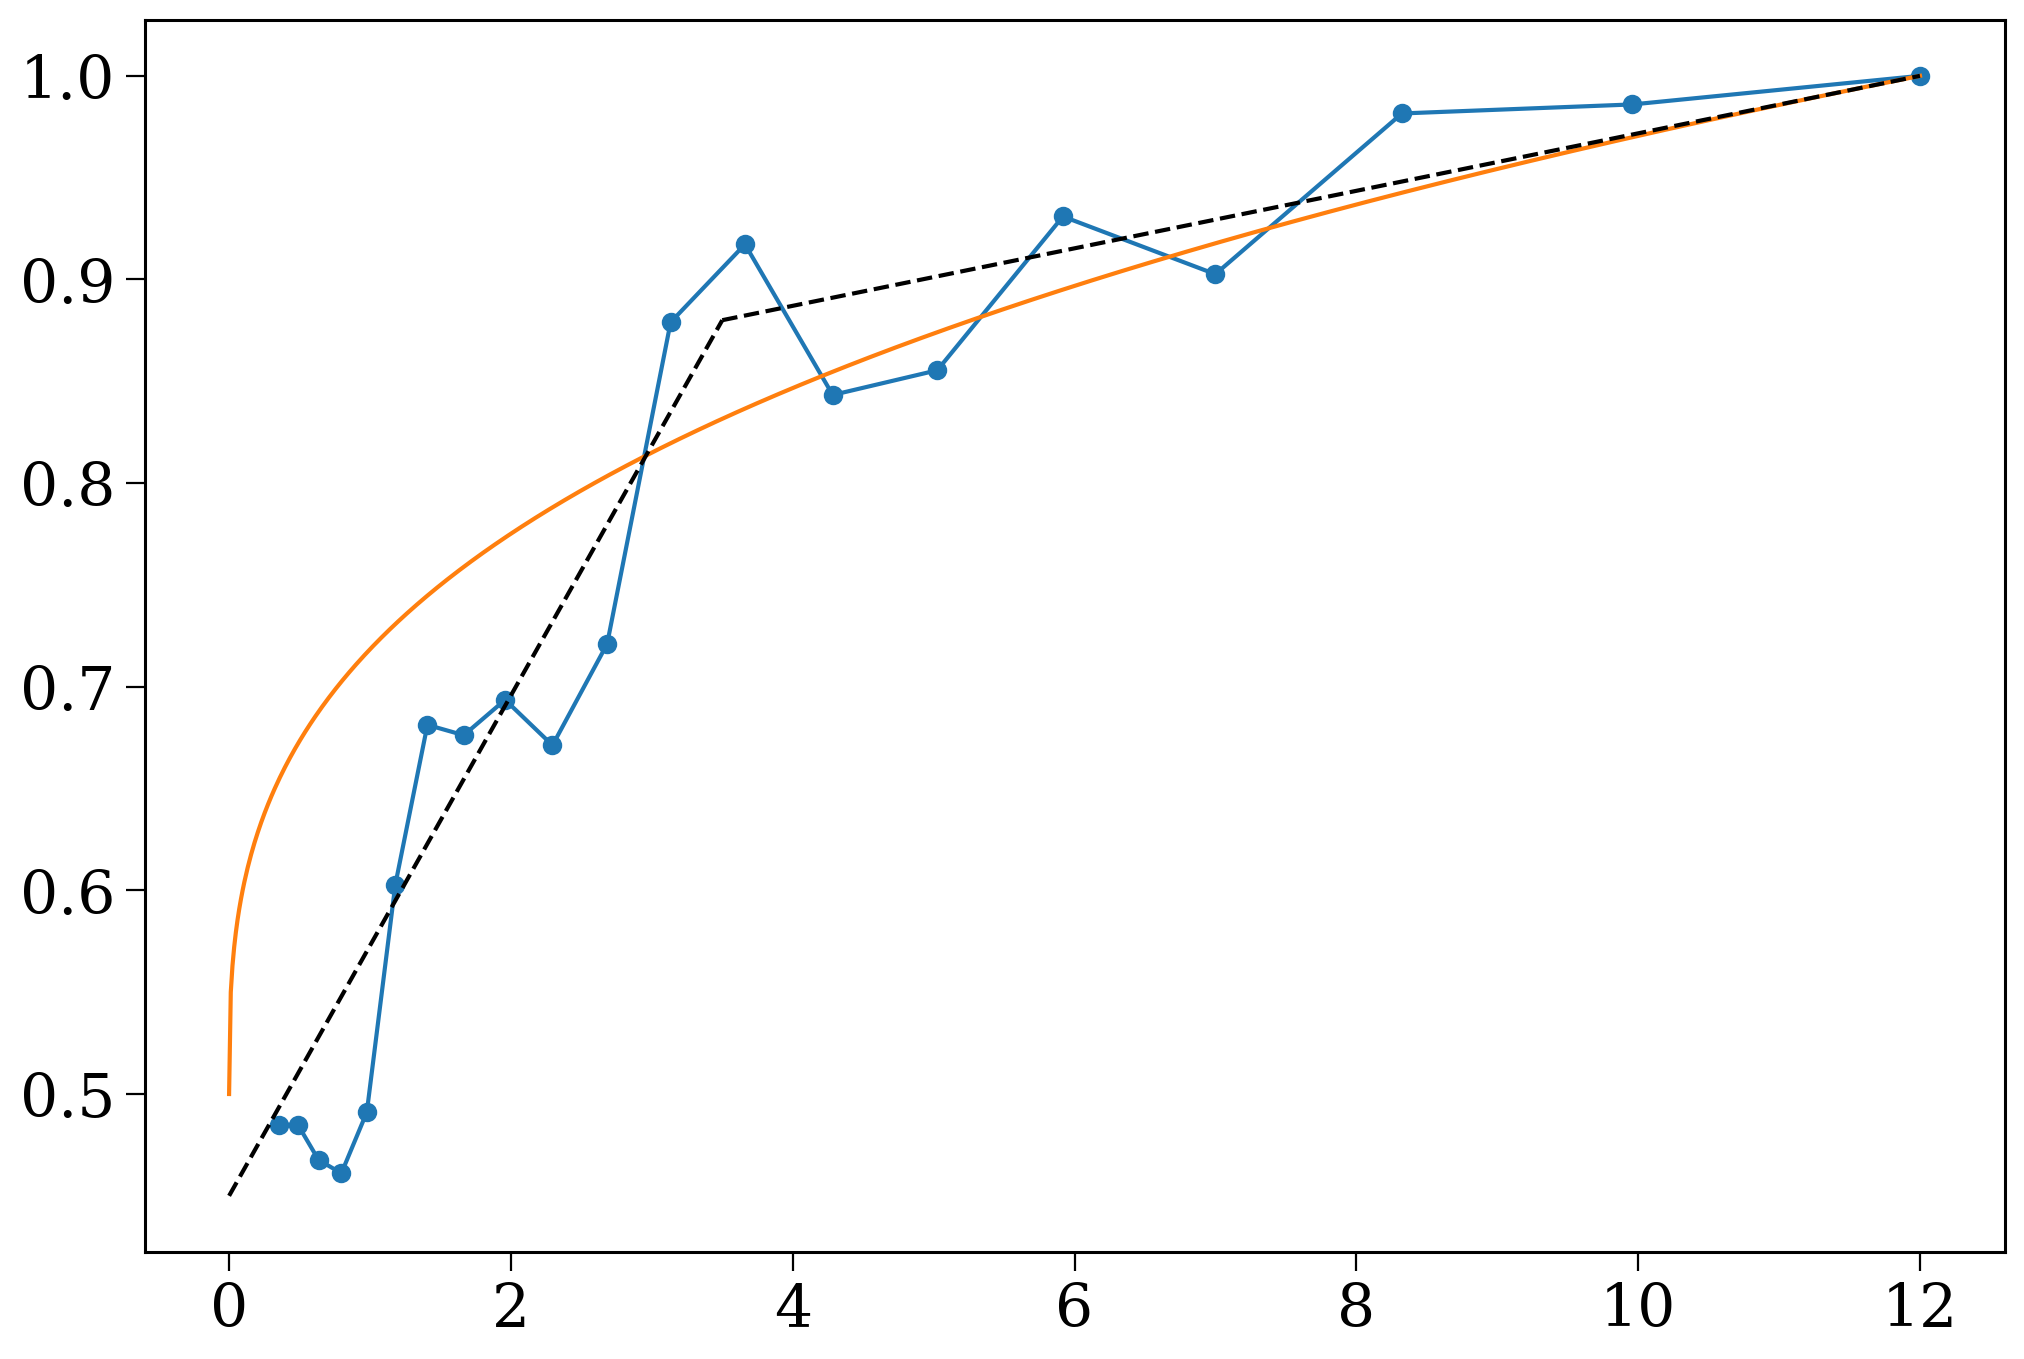

In [45]:
times = cosmo.lookback_time(redshifts).to(u.Gyr)
t_range = np.linspace(0, 12, 1000)
plt.plot(12 * u.Gyr - times, M_at_r / M_at_r.max(), marker='o')

powerlaw = 1/3
plt.plot(t_range, 0.5 + 0.5 * t_range**powerlaw / t_range[-1]**powerlaw)

plt.plot([0, 3.5], [0.45, 0.88], color='k', linestyle='--')
plt.plot([3.5, 12], [0.88, 1.0], color='k', linestyle='--')

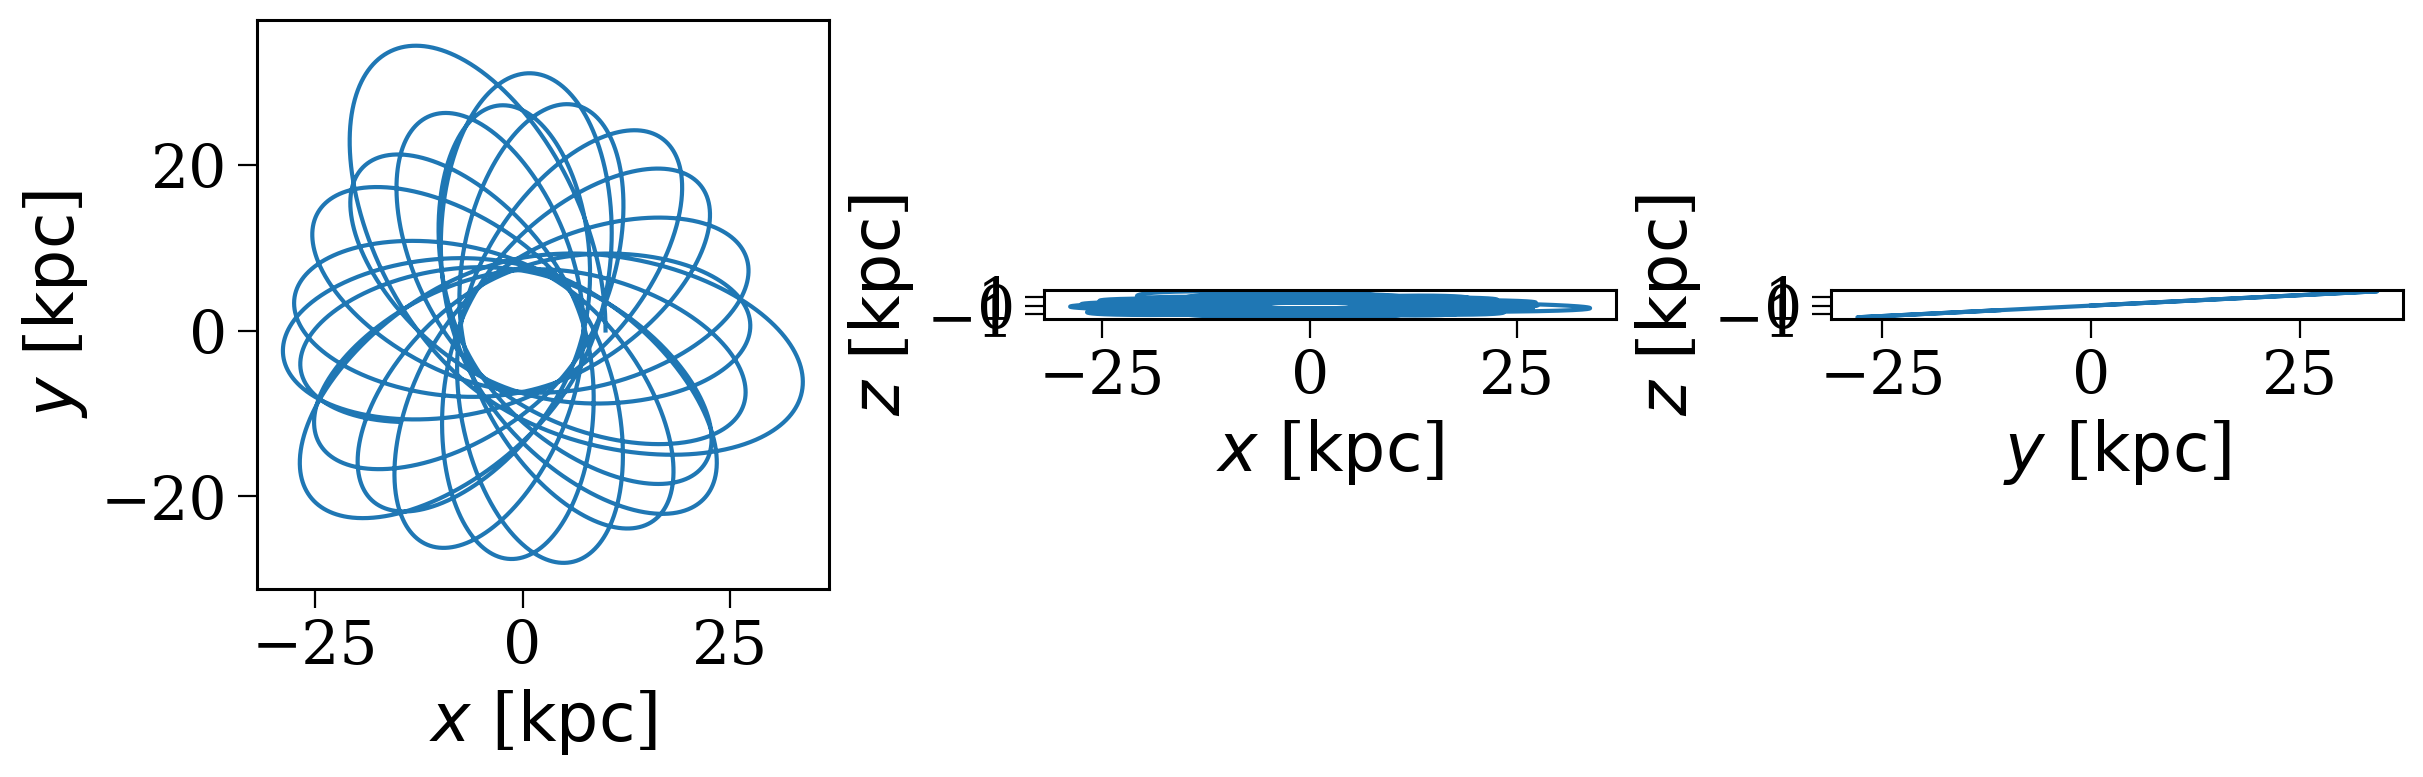

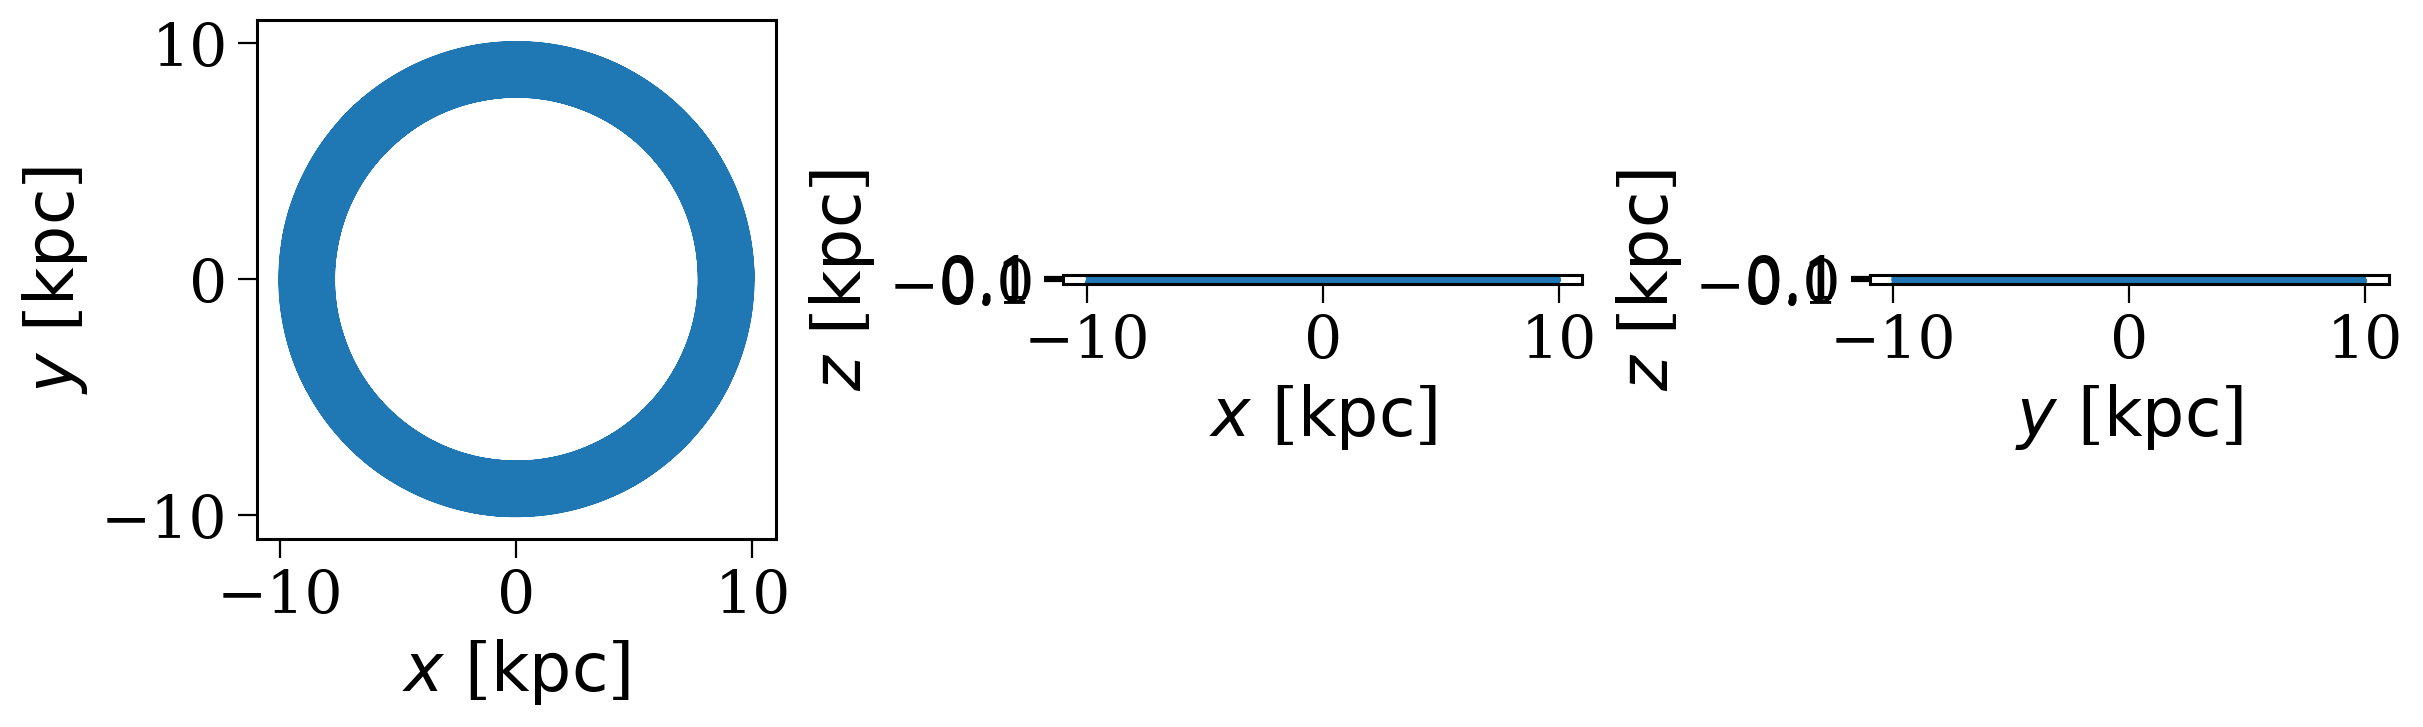

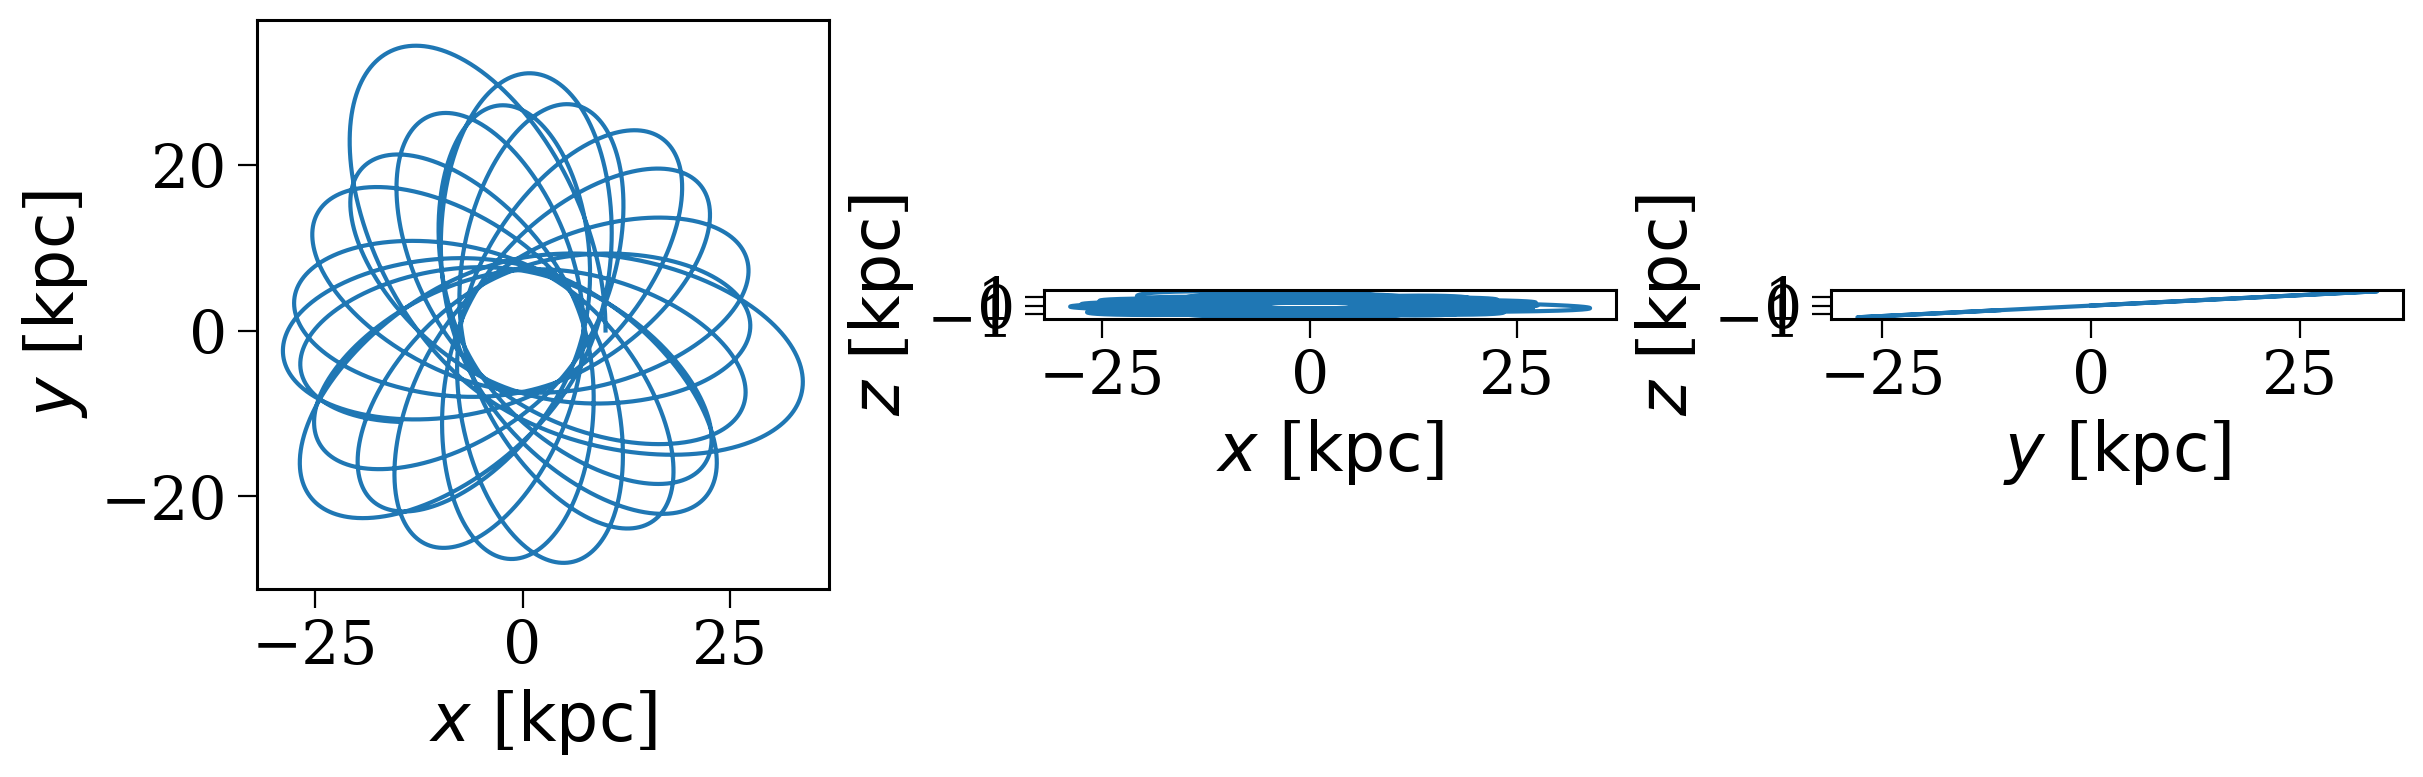

In [80]:
# integrate a test particle orbit in both potentials and compare
import gala.dynamics as gd
w0 = gd.PhaseSpacePosition(pos=[10.0, 0.0, 0.0] * u.kpc, vel=[0, 200.0, 10] * u.km / u.s)
orbit_static = static_mw.integrate_orbit(w0, t1=0, t2=12 * u.Gyr, dt=1 * u.Myr)
orbit_evolving = mw.integrate_orbit(w0, t1=0, t2=12 * u.Gyr, dt=1 * u.Myr)

orbit_static.plot()
orbit_evolving.plot()

In [91]:
simple = gp.TimeInterpolatedPotential(
    gp.NFWPotential, time_knots, m=mass_at_knot, r_s=15.63 * u.kpc, units="galactic"
)

In [ ]:
import cogsworth

p = cogsworth.pop.Population(10, use_default_BSE_settings=True, processes=2, galactic_potential=simple)
p.create_population()

Run for 10 binaries
Ended up with 13 binaries with m1 > 0 solar masses
[2e-02s] Sample initial binaries
[0.3s] Evolve binaries (run COSMIC)


100%|██████████| 13/13 [00:00<00:00, 1729.56it/s]Process ForkPoolWorker-12:
Traceback (most recent call last):
Traceback (most recent call last):
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/pool.py", line 114, in worker
    task = get()
           ^^^^^
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/queues.py", line 367, in get
    return _Forking

KeyboardInterrupt: 

  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)


  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/pool.py", line 114, in worker
    task = get()
           ^^^^^
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/pool.py", line 114, in worker
    task = get()
           ^^^^^
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/queues.py", line 364, in get
    with self._rlock:
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/queues.py", line 365, in get
    res = self._reader.recv_bytes()
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/multiprocessing/connection.py", line 216, in recv_bytes
    buf = self._recv_bytes(maxlength)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^
Keybo

In [84]:

redshift_times = cosmo.lookback_time(redshifts).to(u.Gyr)
plot_times = [12, 10, 8, 6, 4, 2, 0] * u.Gyr
closest_indices = [np.argmin(np.abs(redshift_times - pt)) for pt in plot_times]
closest_indices

[np.int64(0),
 np.int64(8),
 np.int64(13),
 np.int64(15),
 np.int64(17),
 np.int64(18),
 np.int64(19)]

Text(0.5, 0, 'Lookback time [Gyr]')

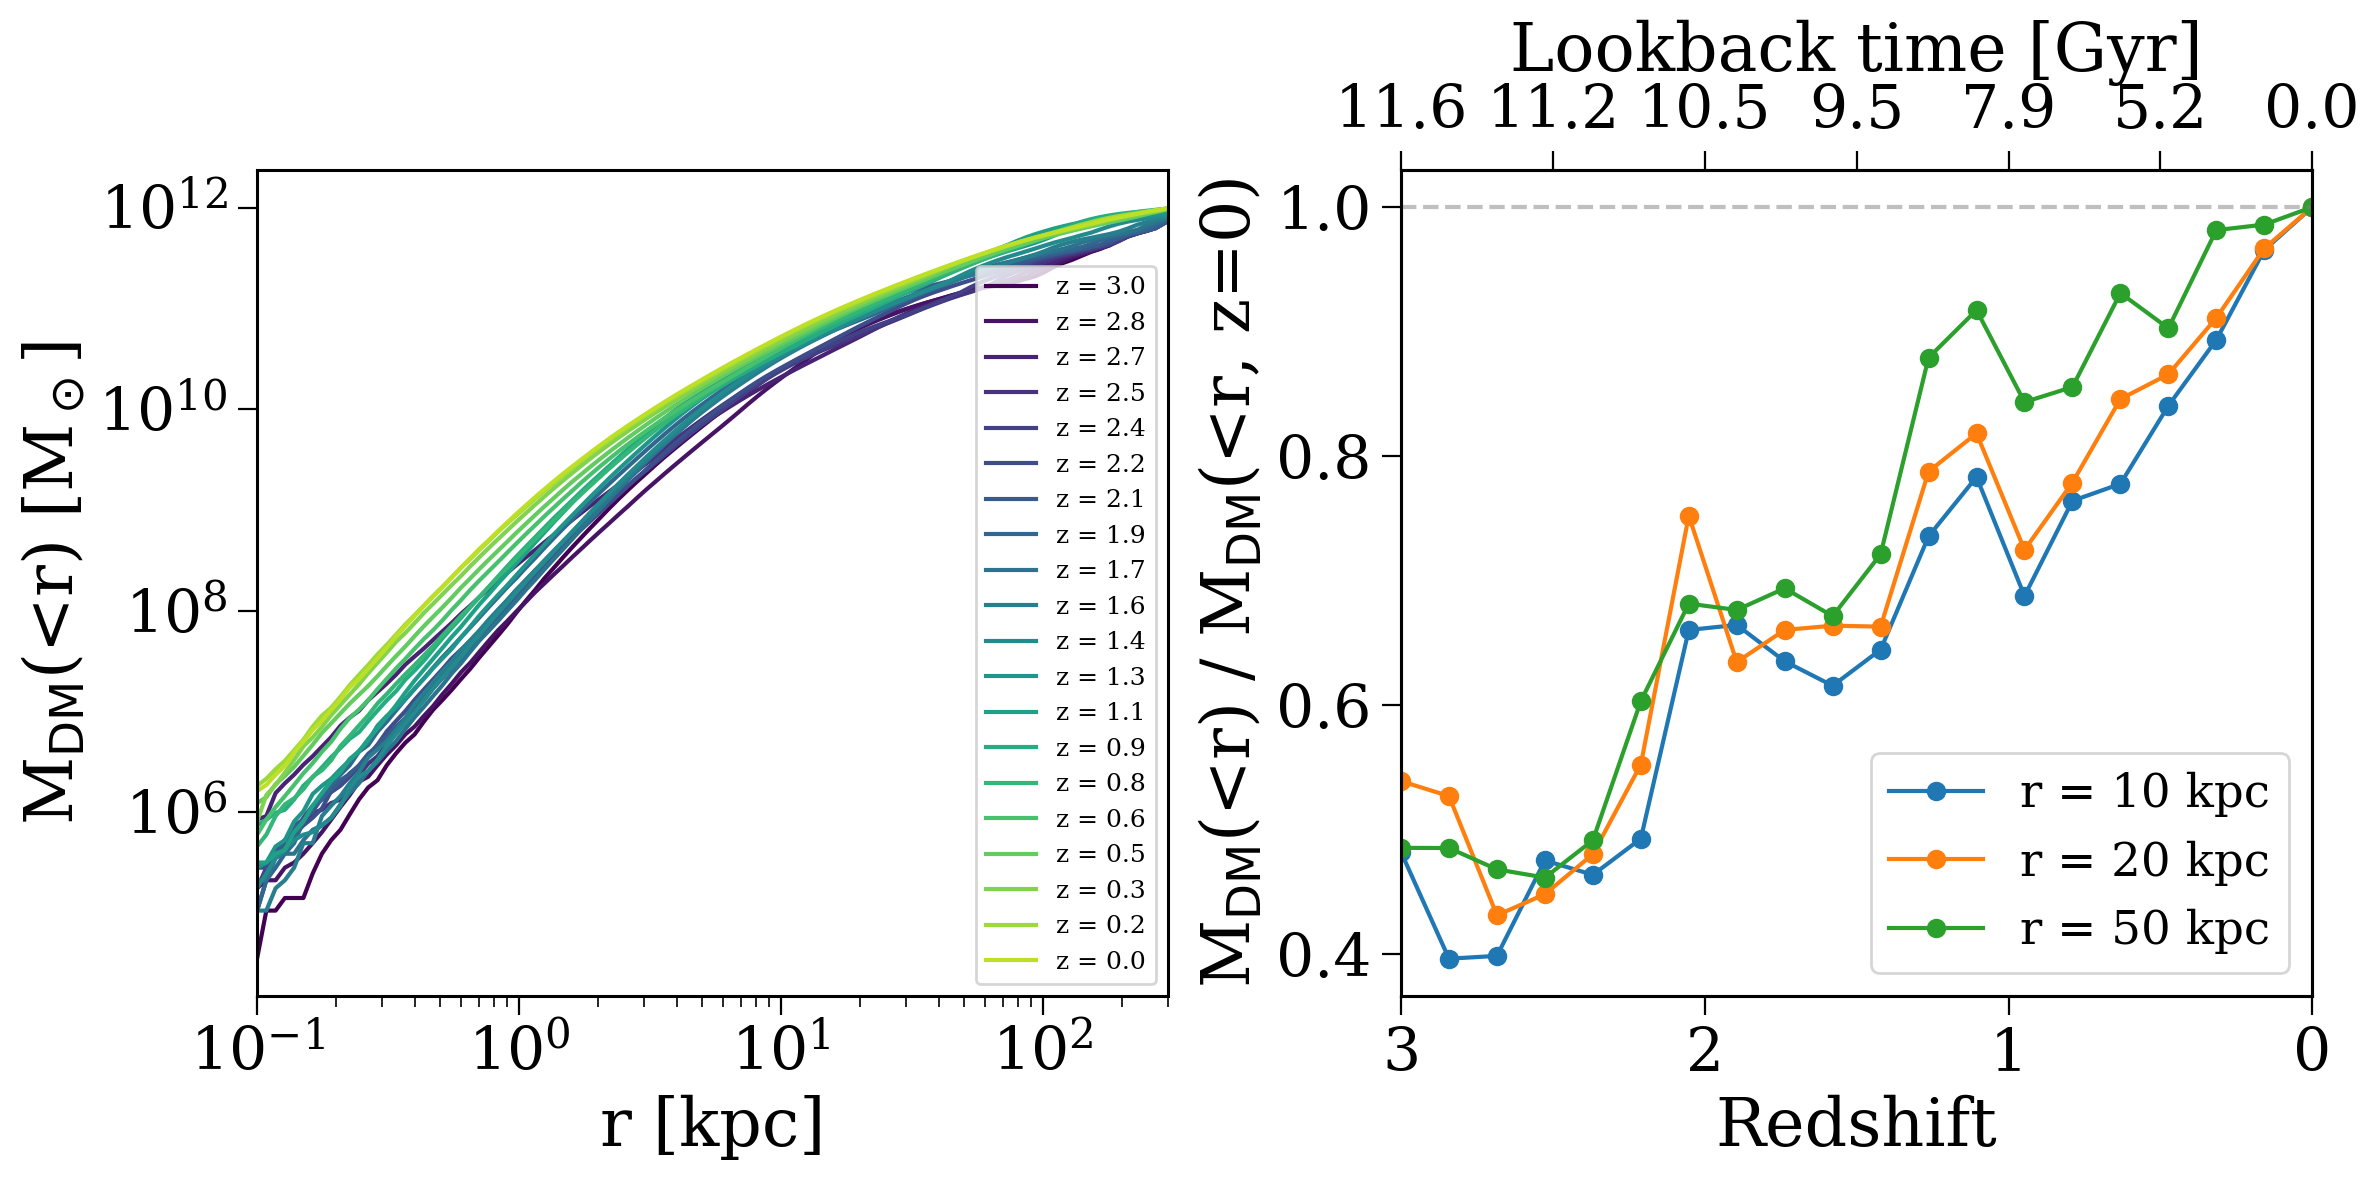

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), layout="tight")

ax = axes[0]
colors = plt.cm.viridis(np.linspace(0, 0.9, len(redshifts)))
for i, z in enumerate(redshifts):
    ax.loglog(r_bins, enclosed_masses[i], color=colors[i], label=f"z = {z:.1f}")
for i, z in enumerate(redshifts):
    ax.loglog(r_bins, enclosed_masses[i], color=colors[i], label=f"z = {z:.1f}")

ax.set_xlabel("r [kpc]")
ax.set_ylabel(r"M$_{\rm DM}$(<r) [M$_\odot$]")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim(0.1, 300)

# ---
ax = axes[1]
fixed_radii = [10, 20, 50]
for r_fix in fixed_radii:
    idx = np.argmin(np.abs(r_bins - r_fix))
    M_at_r = enclosed_masses[:, idx]

    # normalize to z=0 value
    ax.plot(redshifts, M_at_r / M_at_r[-1], "o-", label=f"r = {r_fix} kpc")

ax.set_xlabel("Redshift")
ax.set_ylabel(r"M$_{\rm DM}$(<r) / M$_{\rm DM}$(<r, z=0)")
ax.legend(loc="lower right")
ax.set_xlim(3, 0)
ax.axhline(1, color="gray", ls="--", alpha=0.5)

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())

z_ticks = np.arange(3, 0 - 1e-3, -0.5)
t_labels = [f"{cosmo.lookback_time(z).to(u.Gyr).value:.1f}" for z in z_ticks]
ax_top.set_xticks(z_ticks)
ax_top.set_xticklabels(t_labels)
ax_top.set_xlabel("Lookback time [Gyr]")

ValueError: x and y must have same first dimension, but have shapes (8,) and (20,)

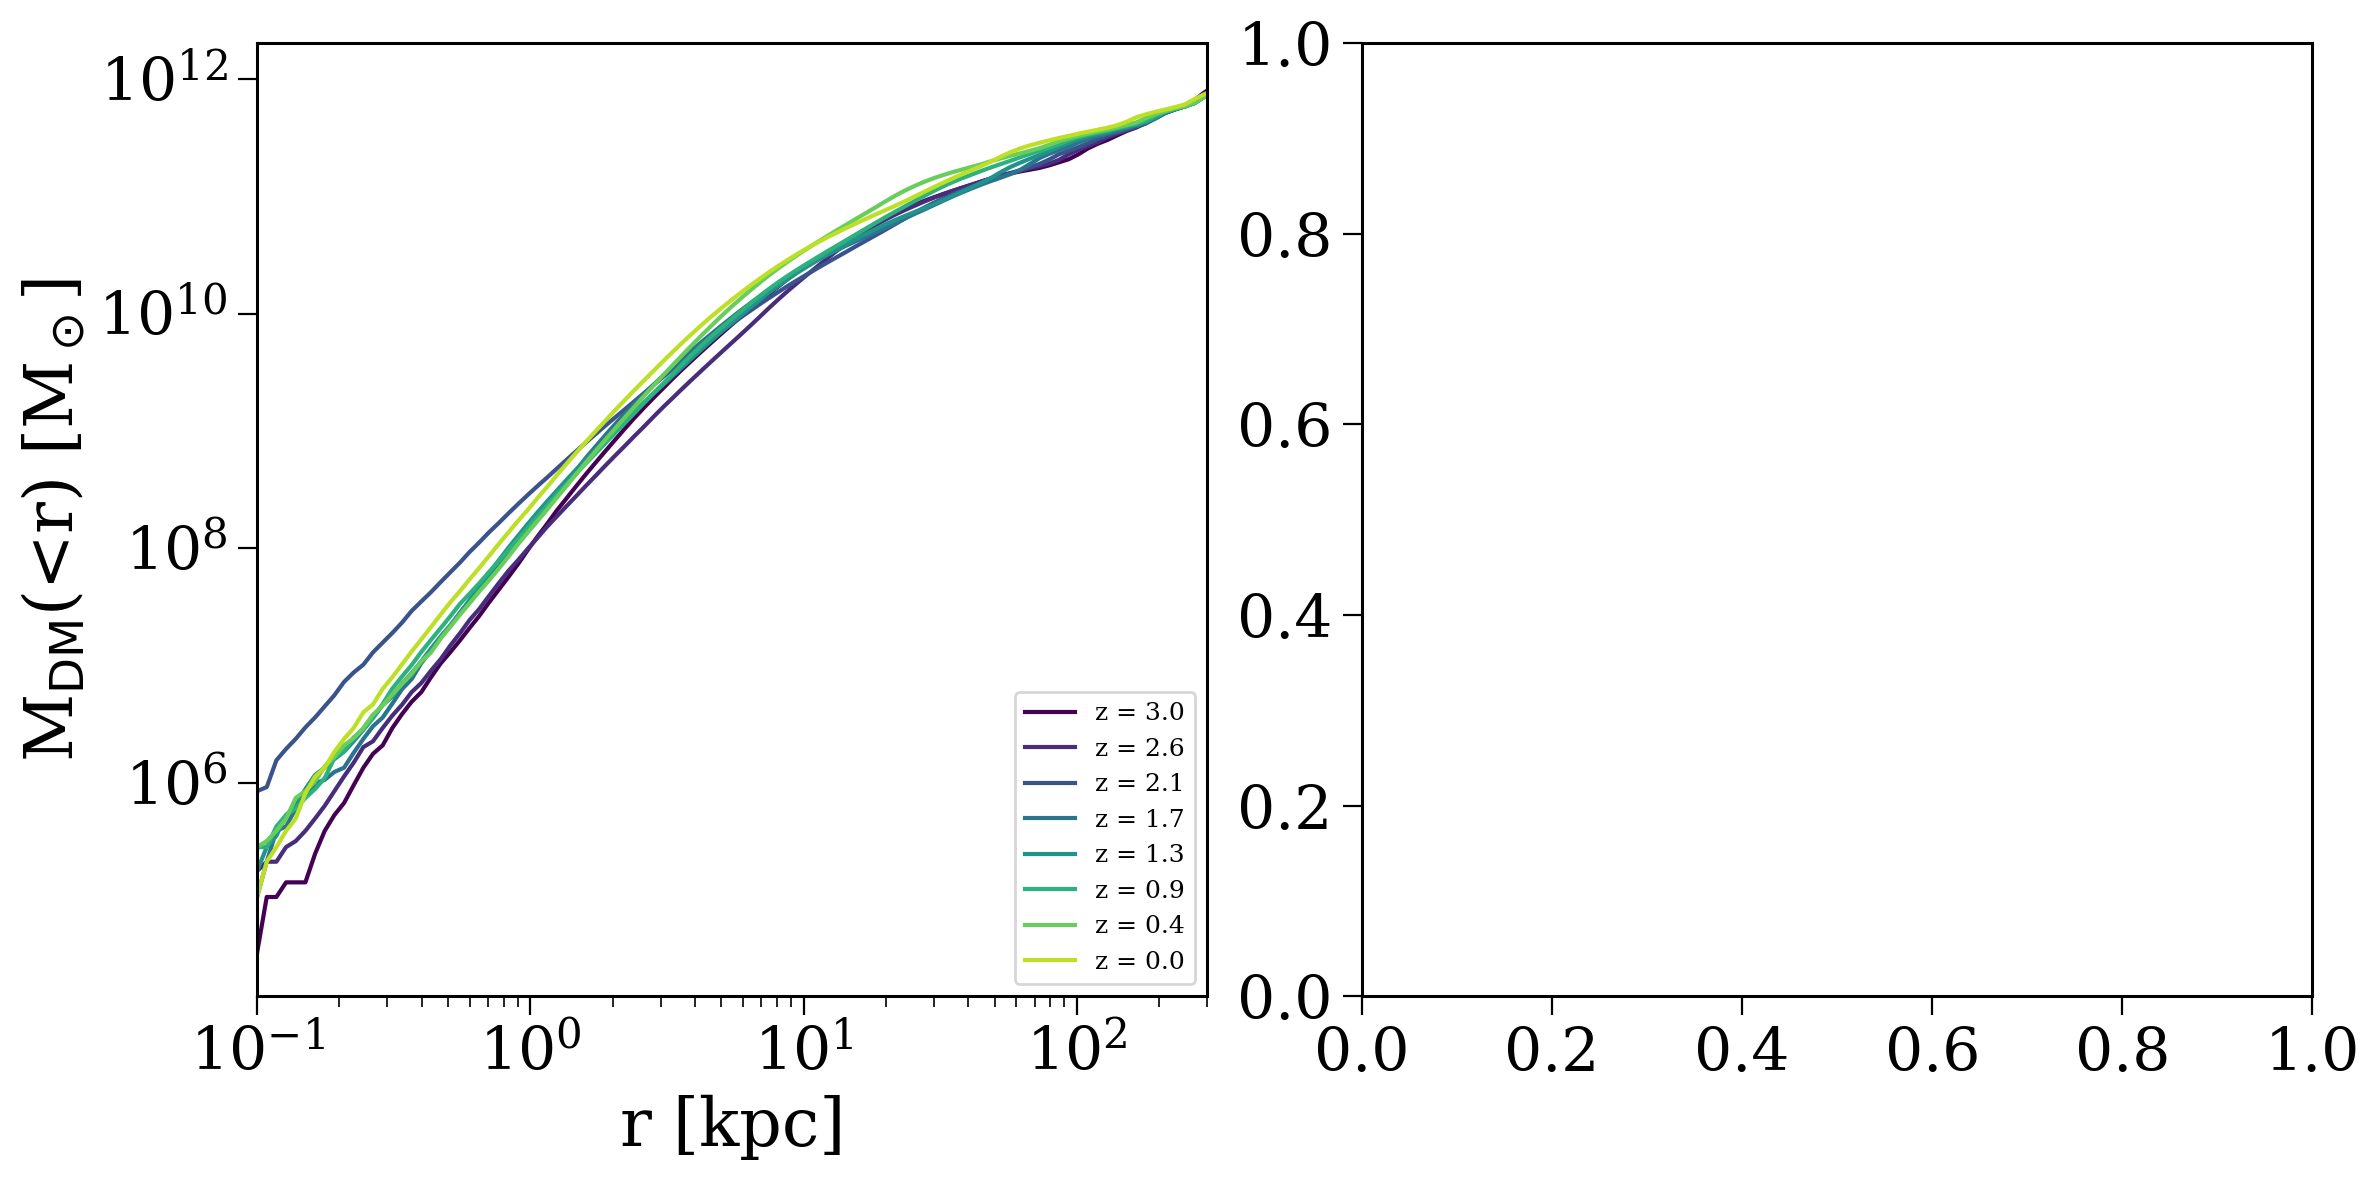

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), layout="tight")

ax = axes[0]
colors = plt.cm.viridis(np.linspace(0, 0.9, len(redshifts)))
for i, z in enumerate(redshifts):
    ax.loglog(r_bins, enclosed_masses[i], color=colors[i], label=f"z = {z:.1f}")

ax.set_xlabel("r [kpc]")
ax.set_ylabel(r"M$_{\rm DM}$(<r) [M$_\odot$]")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim(0.1, 300)

# ---
ax = axes[1]
fixed_radii = [10, 20, 50]
for r_fix in fixed_radii:
    idx = np.argmin(np.abs(r_bins - r_fix))
    M_at_r = enclosed_masses[:, idx]

    # normalize to z=0 value
    ax.plot(redshifts, M_at_r / M_at_r[-1], "o-", label=f"r = {r_fix} kpc")

ax.set_xlabel("Redshift")
ax.set_ylabel(r"M$_{\rm DM}$(<r) / M$_{\rm DM}$(<r, z=0)")
ax.legend(loc="lower right")
ax.set_xlim(3, 0)
ax.axhline(1, color="gray", ls="--", alpha=0.5)

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())

z_ticks = np.arange(3, 0 - 1e-3, -0.5)
t_labels = [f"{cosmo.lookback_time(z).to(u.Gyr).value:.1f}" for z in z_ticks]
ax_top.set_xticks(z_ticks)
ax_top.set_xticklabels(t_labels)
ax_top.set_xlabel("Lookback time [Gyr]")